# Lab 3: Clustering Analysis Using K-Means and K-Medoids Algorithms

**Name:** Saru Bhandari
**Course:** MSCS-634-M20 — Advanced Big Data and Data Mining (2026 Summer, Full Term)
**Lab Assignment:** Lab 3 — Clustering Analysis Using K-Means and K-Medoids Algorithms

---

This notebook applies **K-Means** and **K-Medoids** clustering to the sklearn **Wine Dataset**, then
compares the two methods using the **Silhouette Score** and the **Adjusted Rand Index (ARI)**. Results are
visualised in a shared 2-D PCA space with cluster centres marked.

## Step 1 — Load and Prepare the Dataset

We load the Wine dataset, explore its shape, features, and class balance, then standardise every feature
with z-score normalisation so that no single high-magnitude feature (e.g. `proline`) dominates the
distance calculations used by both algorithms.

In [1]:
# Core imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_wine
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, adjusted_rand_score

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Load the Wine dataset
wine = load_wine()
X = wine.data                      # feature matrix (178 x 13)
y_true = wine.target               # ground-truth class labels (0, 1, 2)
feature_names = wine.feature_names
target_names = wine.target_names

print("Feature matrix shape :", X.shape)
print("Number of features   :", len(feature_names))
print("Number of classes    :", len(target_names))
print("Class names          :", list(target_names))

Feature matrix shape : (178, 13)
Number of features   : 13
Number of classes    : 3
Class names          : [np.str_('class_0'), np.str_('class_1'), np.str_('class_2')]


In [2]:
# Wrap in a DataFrame for readable exploration
df = pd.DataFrame(X, columns=feature_names)
df['target'] = y_true

print("First five rows:")
display(df.head())

print("\nClass distribution (number of samples per wine cultivar):")
print(df['target'].value_counts().sort_index()
      .rename(index={i: name for i, name in enumerate(target_names)}))

First five rows:


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0



Class distribution (number of samples per wine cultivar):
target
class_0    59
class_1    71
class_2    48
Name: count, dtype: int64


In [3]:
# Summary statistics show the very different feature scales
# (e.g. 'proline' is in the hundreds while 'hue' is around 1).
print("Summary statistics (first 6 features):")
display(df[feature_names].describe().T.head(6))

Summary statistics (first 6 features):


,count,mean,std,min,25%,50%,75%,max
alcohol,178.0,13.000618,0.811827,11.03,12.3625,13.050,13.6775,14.83
malic_acid,178.0,2.336348,1.117146,0.74,1.6025,1.865,3.0825,5.80
ash,178.0,2.366517,0.274344,1.36,2.2100,2.360,2.5575,3.23
alcalinity_of_ash,178.0,19.494944,3.339564,10.60,17.2000,19.500,21.5000,30.00
magnesium,178.0,99.741573,14.282484,70.00,88.0000,98.000,107.0000,162.00
total_phenols,178.0,2.295112,0.625851,0.98,1.7425,2.355,2.8000,3.88


In [4]:
# Standardise features with z-score normalisation: mean = 0, std = 1
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("After standardisation:")
print("  mean of each feature (~0):", np.round(X_scaled.mean(axis=0)[:5], 3), "...")
print("  std  of each feature (~1):", np.round(X_scaled.std(axis=0)[:5], 3), "...")

After standardisation:
  mean of each feature (~0): [ 0.  0. -0. -0. -0.] ...
  std  of each feature (~1): [1. 1. 1. 1. 1.] ...


## Step 2 — K-Means Clustering

We run K-Means with `k = 3` (the dataset has three cultivars). After fitting, we evaluate the clustering with:

* **Silhouette Score** — internal measure of how tight and well-separated the clusters are (range −1 to 1, higher is better). It uses only the data and the predicted labels.
* **Adjusted Rand Index (ARI)** — external measure comparing predicted clusters against the true classes (range −1 to 1, 1 = perfect agreement, 0 ≈ random).

In [5]:
# K-Means with k = 3
kmeans = KMeans(n_clusters=3, random_state=RANDOM_STATE, n_init=10)
kmeans_labels = kmeans.fit_predict(X_scaled)

# Evaluation metrics
kmeans_sil = silhouette_score(X_scaled, kmeans_labels)
kmeans_ari = adjusted_rand_score(y_true, kmeans_labels)

print("K-Means (k = 3)")
print(f"  Silhouette Score      : {kmeans_sil:.4f}")
print(f"  Adjusted Rand Index   : {kmeans_ari:.4f}")

K-Means (k = 3)
  Silhouette Score      : 0.2849
  Adjusted Rand Index   : 0.8975


## Step 3 — K-Medoids Clustering

K-Medoids is similar to K-Means but uses **actual data points (medoids)** as cluster centres and minimises
the sum of distances to those medoids, which makes it more robust to outliers.

The popular `sklearn-extra` implementation is currently **incompatible with NumPy 2.x** (it fails to import),
so to keep this notebook fully reproducible on any modern environment we implement the classic **PAM
(Partitioning Around Medoids)** algorithm directly. It uses a build step (random seeded initialisation)
followed by the standard swap step that keeps exchanging medoids with non-medoids whenever doing so lowers
the total clustering cost.

In [6]:
from sklearn.metrics import pairwise_distances

def kmedoids_pam(D, k, max_iter=300, random_state=42):
    """Classic PAM (Partitioning Around Medoids) clustering.

    Parameters
    ----------
    D : (n, n) precomputed distance matrix
    k : number of clusters
    Returns
    -------
    medoids : indices of the k chosen medoid points
    labels  : cluster assignment for every point
    cost    : final total within-cluster distance
    """
    rng = np.random.RandomState(random_state)
    n = D.shape[0]

    # --- Build step: pick k distinct points at random as initial medoids ---
    medoids = list(rng.choice(n, size=k, replace=False))

    def total_cost(meds):
        # each point joins its nearest medoid; cost is the sum of those distances
        return D[:, meds].min(axis=1).sum()

    current_cost = total_cost(medoids)

    # --- Swap step: try replacing each medoid with each non-medoid ---
    for _ in range(max_iter):
        best_swap, best_cost = None, current_cost
        medoid_set = set(medoids)
        non_medoids = [i for i in range(n) if i not in medoid_set]

        for mi, m in enumerate(medoids):
            for o in non_medoids:
                trial = medoids.copy()
                trial[mi] = o
                c = total_cost(trial)
                if c < best_cost:
                    best_cost, best_swap = c, (mi, o)

        if best_swap is None:        # no swap improves the cost -> converged
            break
        mi, o = best_swap
        medoids[mi] = o
        current_cost = best_cost

    medoids = np.array(medoids)
    labels = D[:, medoids].argmin(axis=1)
    return medoids, labels, current_cost

In [7]:
# Euclidean distance matrix on the standardised data
D = pairwise_distances(X_scaled, metric='euclidean')

medoid_idx, kmedoids_labels, kmedoids_cost = kmedoids_pam(D, k=3, random_state=RANDOM_STATE)

# Evaluation metrics (same as K-Means)
kmedoids_sil = silhouette_score(X_scaled, kmedoids_labels)
kmedoids_ari = adjusted_rand_score(y_true, kmedoids_labels)

print("K-Medoids / PAM (k = 3)")
print(f"  Medoid point indices  : {medoid_idx}")
print(f"  Final clustering cost : {kmedoids_cost:.4f}")
print(f"  Silhouette Score      : {kmedoids_sil:.4f}")
print(f"  Adjusted Rand Index   : {kmedoids_ari:.4f}")

K-Medoids / PAM (k = 3)
  Medoid point indices  : [ 35 106 148]
  Final clustering cost : 500.9292
  Silhouette Score      : 0.2676
  Adjusted Rand Index   : 0.7411


## Step 4 — Visualise and Compare Results

The data lives in 13 dimensions, so we project it to **2 principal components** purely for plotting. The
clustering itself was performed on all 13 standardised features. Cluster centres are overlaid: **×** marks
the K-Means centroids and **★** marks the K-Medoids medoids (which are real wine samples).

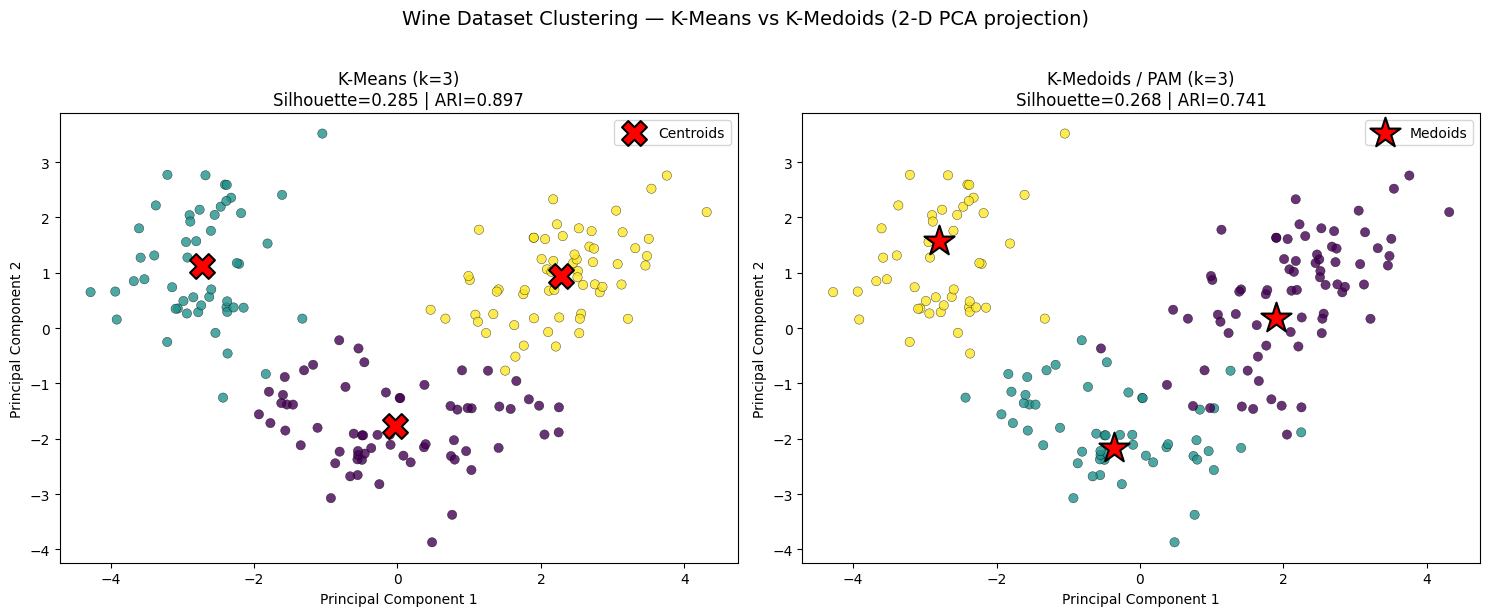

In [8]:
# Project to 2-D with PCA for visualisation only
pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_scaled)

# Centroids: project K-Means centroids; medoids are actual points
kmeans_centers_pca = pca.transform(kmeans.cluster_centers_)
medoid_centers_pca = X_pca[medoid_idx]

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# --- K-Means panel ---
sc0 = axes[0].scatter(X_pca[:, 0], X_pca[:, 1], c=kmeans_labels,
                      cmap='viridis', s=45, alpha=0.8, edgecolor='k', linewidth=0.3)
axes[0].scatter(kmeans_centers_pca[:, 0], kmeans_centers_pca[:, 1],
                c='red', marker='X', s=320, edgecolor='black', linewidth=1.5, label='Centroids')
axes[0].set_title(f"K-Means (k=3)\nSilhouette={kmeans_sil:.3f} | ARI={kmeans_ari:.3f}", fontsize=12)
axes[0].set_xlabel("Principal Component 1")
axes[0].set_ylabel("Principal Component 2")
axes[0].legend(loc='upper right')

# --- K-Medoids panel ---
sc1 = axes[1].scatter(X_pca[:, 0], X_pca[:, 1], c=kmedoids_labels,
                      cmap='viridis', s=45, alpha=0.8, edgecolor='k', linewidth=0.3)
axes[1].scatter(medoid_centers_pca[:, 0], medoid_centers_pca[:, 1],
                c='red', marker='*', s=520, edgecolor='black', linewidth=1.5, label='Medoids')
axes[1].set_title(f"K-Medoids / PAM (k=3)\nSilhouette={kmedoids_sil:.3f} | ARI={kmedoids_ari:.3f}", fontsize=12)
axes[1].set_xlabel("Principal Component 1")
axes[1].set_ylabel("Principal Component 2")
axes[1].legend(loc='upper right')

plt.suptitle("Wine Dataset Clustering — K-Means vs K-Medoids (2-D PCA projection)", fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('clustering_comparison.png', dpi=120, bbox_inches='tight')
plt.show()

In [9]:
# Side-by-side metric summary
summary = pd.DataFrame({
    'Silhouette Score':     [kmeans_sil, kmedoids_sil],
    'Adjusted Rand Index':  [kmeans_ari, kmedoids_ari],
}, index=['K-Means', 'K-Medoids (PAM)']).round(4)

print("Performance comparison:")
display(summary)

Performance comparison:


,Silhouette Score,Adjusted Rand Index
K-Means,0.2849,0.8975
K-Medoids (PAM),0.2676,0.7411


### Analysis and Comparison

**Which algorithm produced better-defined clusters?**
The two methods are almost tied on the Silhouette Score (K-Means ≈ 0.285 vs K-Medoids ≈ 0.268), so the
*internal* tightness and separation of the clusters is very similar. The clearer gap is in the Adjusted
Rand Index, where K-Means (≈ 0.90) agrees with the true cultivar labels noticeably more than K-Medoids
(≈ 0.74). In short, both find three reasonable clusters, but K-Means lines them up with the real classes
better here. This fits the data: the Wine clusters are roughly spherical and free of strong outliers, which
is exactly the setting K-Means is optimised for, since it minimises squared Euclidean distance to
mean-valued centroids.

**Differences in cluster shape and centre positioning.**
The bulk of the points are assigned the same way by both methods; the ARI gap comes mainly from border
points around the overlap of two cultivars that K-Medoids assigns differently. The most visible structural
difference is the centres themselves. K-Means centroids (×) are *computed averages* and can sit in empty
space between points, whereas K-Medoids medoids (★) are *real wine samples* (indices 35, 106, 148), so they
always land on an actual observation inside a cluster. That makes the K-Medoids centres directly
interpretable as representative wines, at the cost of a little flexibility in where the centre can sit.

**When is each method preferable?**
K-Means is the better default when clusters are compact and roughly spherical, the data is clean, and speed
matters — it is fast and scales to large datasets. K-Medoids is preferable when the data contains outliers
or noise, when you need the cluster centre to be a genuine, interpretable data point, or when you want to
cluster with a non-Euclidean distance (e.g. Manhattan or a custom metric) where a "mean" is not meaningful.
Its robustness comes at a higher computational cost, which is why it shines on smaller or noisier datasets
rather than very large ones.